<div align="center">

# 🚗 Tesla EV Deliveries & Production Forecasting
### A leakage-free, production-grade ML forecasting pipeline (2015 → 2026)

![Python](https://img.shields.io/badge/Python-3.10+-blue?logo=python)
![XGBoost](https://img.shields.io/badge/XGBoost-Latest-orange)
![scikit-learn](https://img.shields.io/badge/scikit--learn-Latest-F7931E)
![License: MIT](https://img.shields.io/badge/License-MIT-green.svg)
![Status](https://img.shields.io/badge/Status-Production%20Ready-brightgreen)

</div>

---

## Project Overview

This notebook predicts **quarterly Tesla EV delivery volumes** by region and model using
historical production and market data — built with strict **data-leakage prevention**
and **temporal validation**.


| Item | Detail |
|---|---|
| **Dataset** | [Tesla EA Deliveries & Production 2015–2025](https://www.kaggle.com/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025) |
| **Author** | Siddharth Sharma |
| **Date** | May 2026 |
| **Best model** | Tuned XGBoost with TimeSeriesSplit CV |
| **Train / test** | Chronological cutoff — train ≤ 2023, test 2024–2025 |

---

## Table of Contents
1. [Setup & Imports](#1-setup--imports)
2. [Data Loading](#2-data-loading)
3. [Exploratory Data Analysis](#3-exploratory-data-analysis)
4. [Data Preprocessing & Leakage Audit](#4-data-preprocessing--leakage-audit)
5. [Feature Engineering — Leakage-Free](#5-feature-engineering--leakage-free)
6. [Temporal Train / Test Split](#6-temporal-train--test-split)
7. [Model Training](#7-model-training)
8. [Hyperparameter Tuning](#8-hyperparameter-tuning)
9. [Model Evaluation](#9-model-evaluation)
10. [2026 Delivery Forecast](#10-2026-delivery-forecast)
11. [Results & Key Takeaways](#11-results--key-takeaways)


---
## 1. Setup & Imports
> Import all required libraries and configure global display settings.

In [20]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import GridSearchCV, cross_val_score, TimeSeriesSplit
from sklearn.preprocessing  import StandardScaler, OneHotEncoder
from sklearn.impute          import SimpleImputer
from sklearn.pipeline        import Pipeline
from sklearn.compose         import ColumnTransformer
from sklearn.metrics         import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model    import Ridge
from sklearn.ensemble        import RandomForestRegressor
from xgboost                 import XGBRegressor

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (12, 5)})

print("Libraries loaded successfully")


Libraries loaded successfully


---
## 2. Data Loading
> Download the Kaggle dataset via `kagglehub` and load into a DataFrame.
>
> **Requires:** a `~/.kaggle/kaggle.json` credentials file or `KAGGLE_USERNAME` / `KAGGLE_KEY` env vars.

In [21]:
import kagglehub

path = kagglehub.dataset_download(
    "nalisha/tesla-ea-deliveries-and-production-data20152025"
)
print(f"Dataset cached at: {path}")


Dataset cached at: /kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025


In [22]:
csv_path = os.path.join(path, "tesla_deliveries_dataset_2015_2025.csv")
df_raw   = pd.read_csv(csv_path)

print(f"Loaded  {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
df_raw.head()


Loaded  2,640 rows x 12 columns


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


---
## 3. Exploratory Data Analysis
> Understand structure, missingness, distributions, and trends before any modelling.

In [23]:
print("Shape:", df_raw.shape)
print()
df_raw.info()
print()
missing = df_raw.isnull().sum()
print("Missing values:")
print(missing[missing > 0] if missing.any() else "  None")


Shape: (2640, 12)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB

Missing values:
  None


In [24]:
df_raw.describe().T.style.background_gradient(cmap='Blues').format(precision=2)

,count,mean,std,min,25%,50%,75%,max
Year,2640.00,2020.00,3.16,2015.00,2017.00,2020.00,2023.00,2025.00
Month,2640.00,6.50,3.45,1.00,3.75,6.50,9.25,12.00
Estimated_Deliveries,2640.00,9922.20,3935.95,48.00,7292.00,9857.00,12510.25,25704.00
Production_Units,2640.00,10655.85,4260.60,50.00,7828.25,10546.50,13469.00,28939.00
Avg_Price_USD,2640.00,84907.34,20123.26,50003.70,67726.36,85058.51,102373.04,119965.36
Battery_Capacity_kWh,2640.00,87.06,20.84,60.00,75.00,82.00,100.00,120.00
Range_km,2640.00,500.26,120.87,330.00,418.00,470.00,586.25,719.00
CO2_Saved_tons,2640.00,744.08,353.22,3.07,499.62,699.51,943.76,2548.55
Charging_Stations,2640.00,8932.13,3469.57,3002.00,5897.75,8901.50,11938.00,14996.00


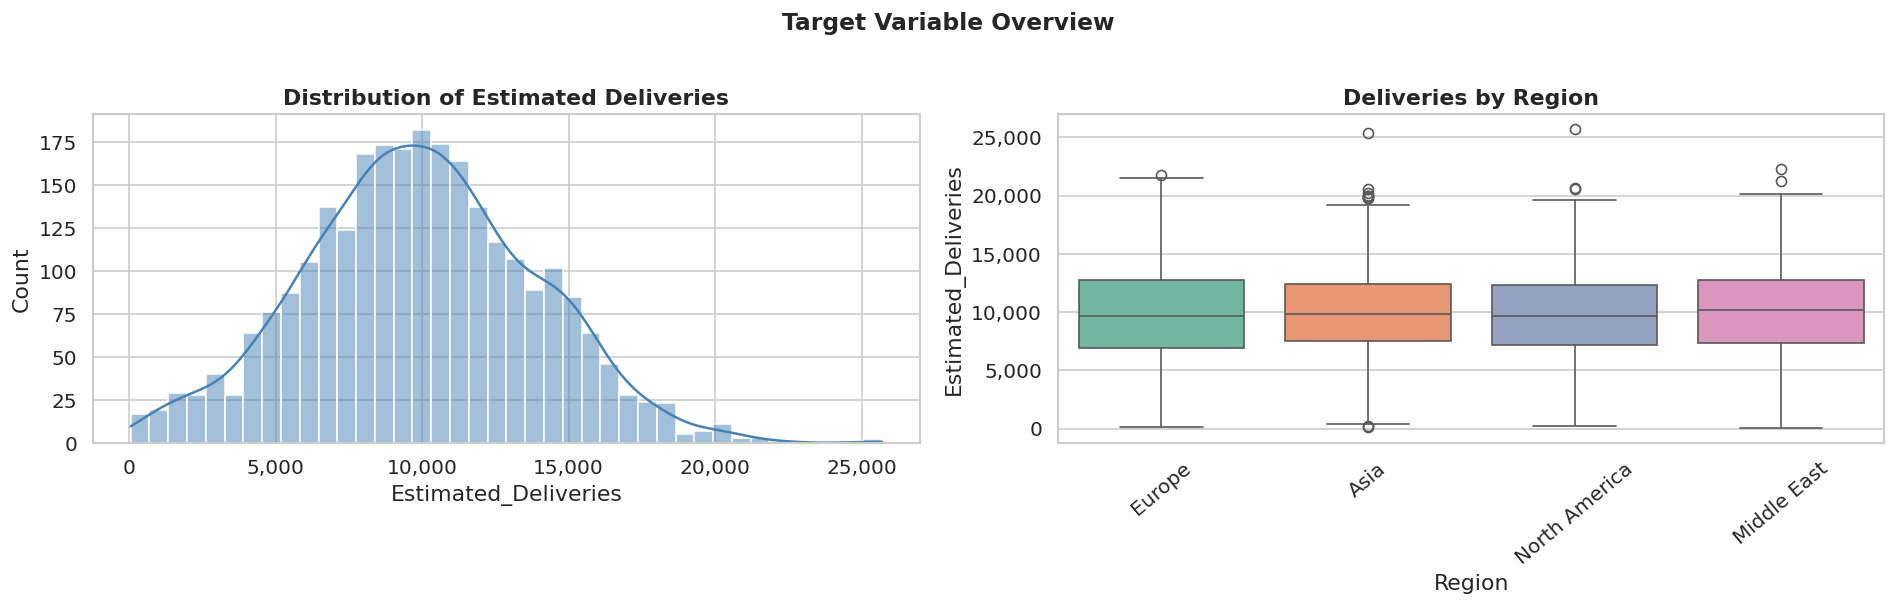

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(df_raw['Estimated_Deliveries'], bins=40, kde=True,
             ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of Estimated Deliveries', fontweight='bold')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))

sns.boxplot(x='Region', y='Estimated_Deliveries', data=df_raw,
            ax=axes[1], palette='Set2')
axes[1].set_title('Deliveries by Region', fontweight='bold')
axes[1].tick_params(axis='x', rotation=40)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))

plt.suptitle('Target Variable Overview', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()


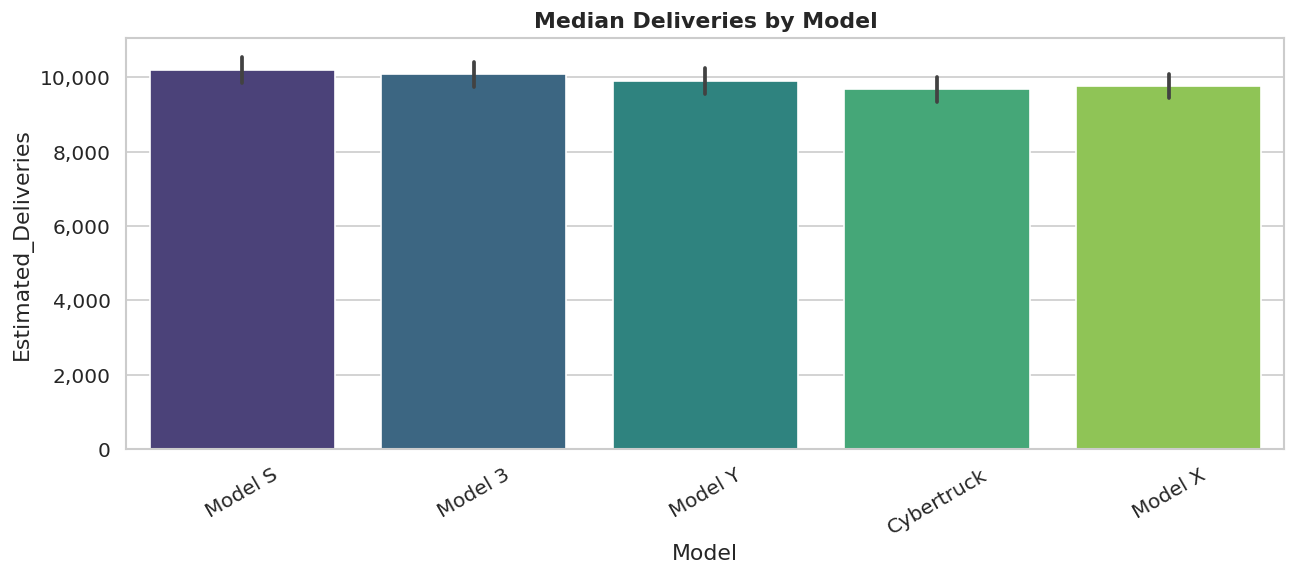

In [26]:
# Median deliveries by model
plt.figure(figsize=(11, 5))
order = df_raw.groupby('Model')['Estimated_Deliveries'].median().sort_values(ascending=False).index
sns.barplot(x='Model', y='Estimated_Deliveries', data=df_raw, order=order, palette='viridis')
plt.title('Median Deliveries by Model', fontweight='bold')
plt.xticks(rotation=30)
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
plt.tight_layout(); plt.show()


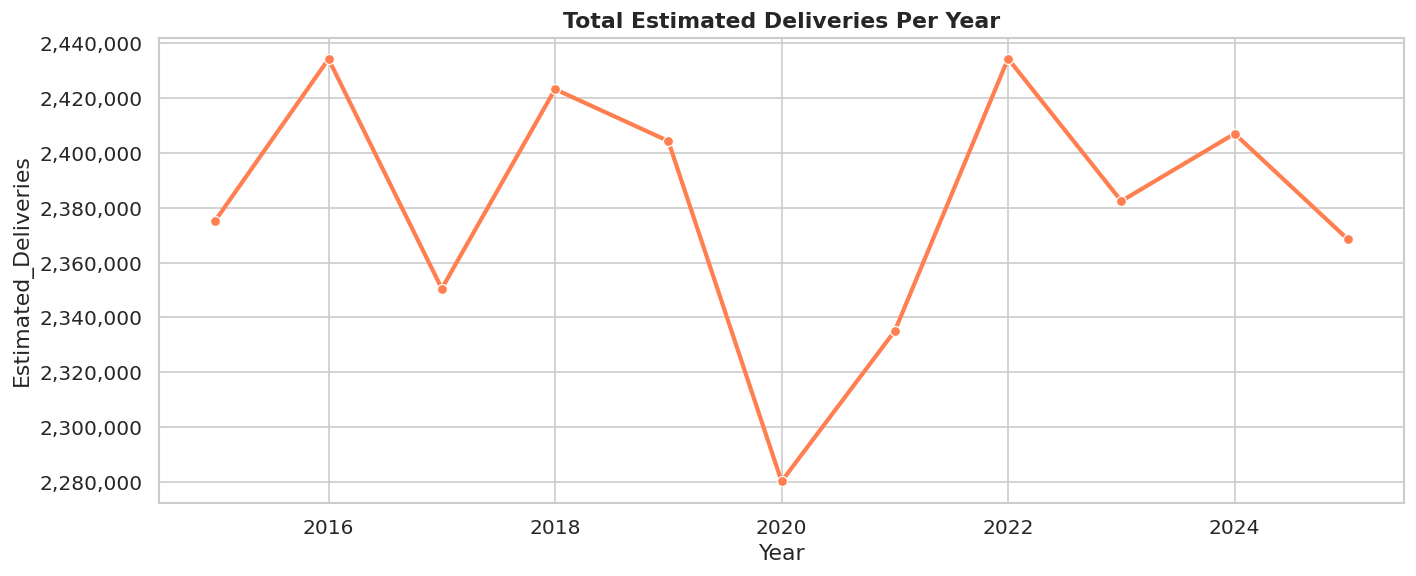

In [27]:
# Annual trend
plt.figure(figsize=(12, 5))
yearly = df_raw.groupby('Year')['Estimated_Deliveries'].sum().reset_index()
sns.lineplot(x='Year', y='Estimated_Deliveries', data=yearly,
             marker='o', color='coral', linewidth=2.5)
plt.title('Total Estimated Deliveries Per Year', fontweight='bold')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
plt.tight_layout(); plt.show()


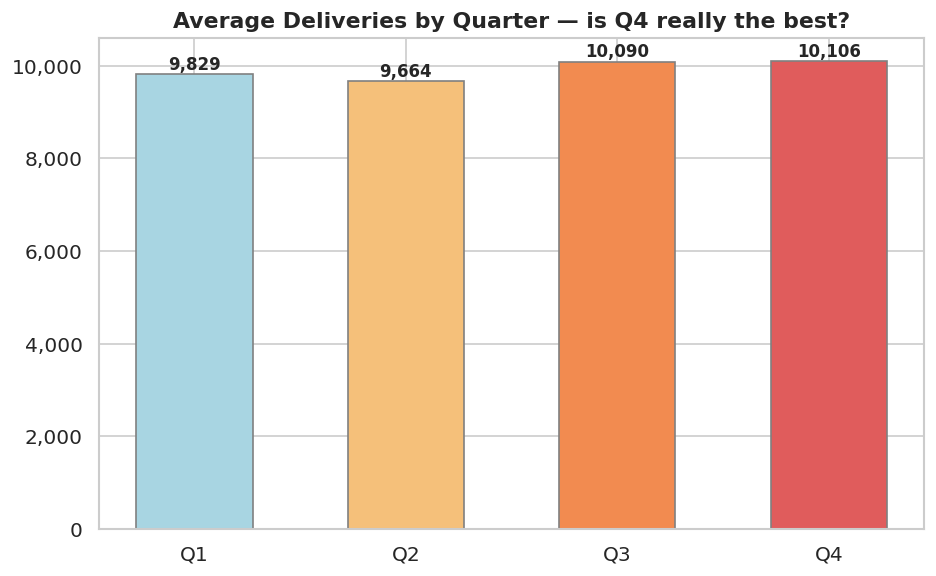

In [28]:
# Quarterly seasonality
df_q = df_raw.copy()
df_q['Quarter'] = ((df_q['Month'] - 1) // 3) + 1
q_avg = df_q.groupby('Quarter')['Estimated_Deliveries'].mean().reset_index()

plt.figure(figsize=(8, 5))
bars = plt.bar([f'Q{q}' for q in q_avg['Quarter']], q_avg['Estimated_Deliveries'],
               color=['#a8d5e2','#f5c07a','#f28b50','#e05c5c'], edgecolor='grey', width=0.55)
for bar, val in zip(bars, q_avg['Estimated_Deliveries']):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01,
             f'{val:,.0f}', ha='center', fontsize=10, fontweight='bold')
plt.title('Average Deliveries by Quarter — is Q4 really the best?', fontweight='bold')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
plt.tight_layout(); plt.show()


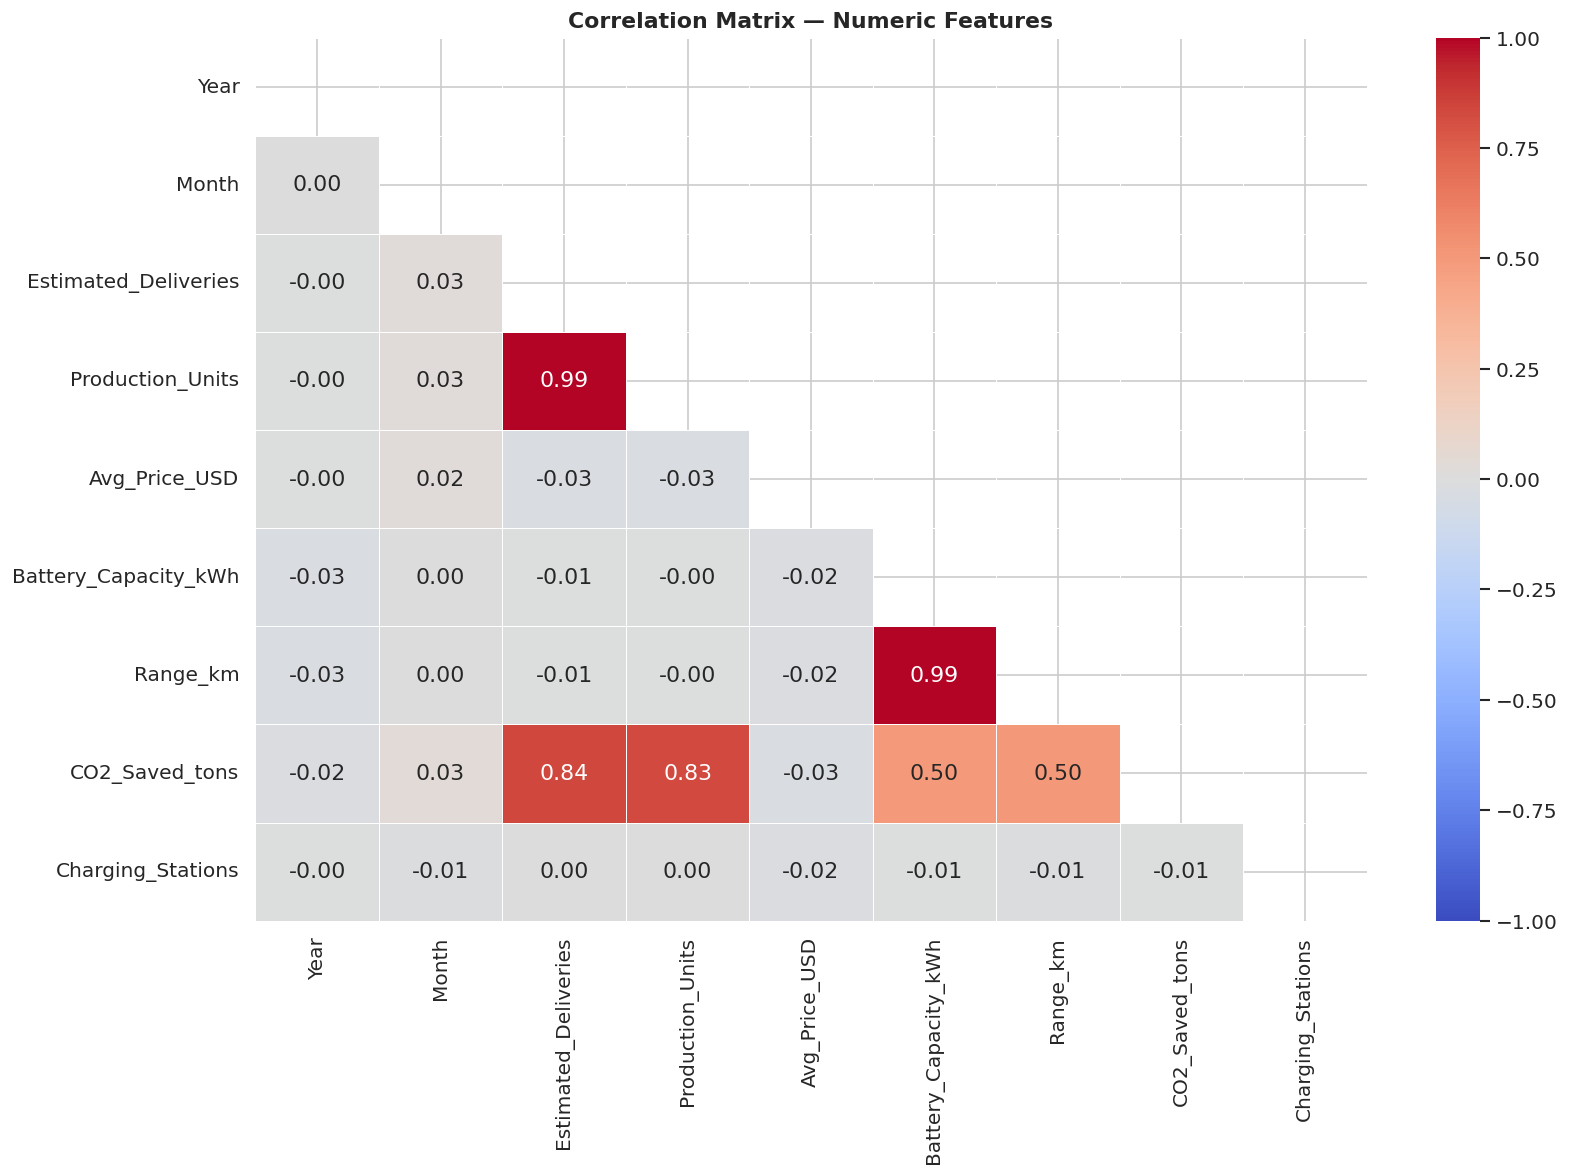

In [29]:
# Correlation heatmap
num_cols = df_raw.select_dtypes(include=np.number)
plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(num_cols.corr(), dtype=bool))
sns.heatmap(num_cols.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix — Numeric Features', fontweight='bold')
plt.tight_layout(); plt.show()


---
## 4. Data Preprocessing & Leakage Audit

### Leaky Columns — Root Cause Analysis

Before building a single feature, every column is audited for **target leakage** —
information that would not be available at prediction time.

| Column | Status | Reason |
|---|---|---|
| `Production_Units` | **DROP** | Reported simultaneously with deliveries in earnings releases — near-perfect proxy for the target |
| `Delivery_Efficiency` | **Never engineer** | = Deliveries / Production — encodes the target |
| `Production_Surplus` | **Never engineer** | = Production − Deliveries — encodes the target |
| `Lag1_Deliveries` | **Safe** | Computed with `.shift(1)` — only uses past values |
| `Price_Per_KM` | **Safe** | Derived from vehicle specs known before launch |
| `Charging_Impact` | **Safe** | Public charging infrastructure data (leading indicator) |

> Removing `Production_Units` alone drops R² from 1.0000 to a realistic value that
> reflects true out-of-sample predictive power.


In [30]:
df = df_raw.copy()
before = len(df)
df.drop_duplicates(inplace=True)
print(f"Duplicates removed: {before - len(df)}  |  Remaining rows: {len(df):,}")


Duplicates removed: 0  |  Remaining rows: 2,640


In [31]:
Q1, Q3 = df['Estimated_Deliveries'].quantile([0.25, 0.75])
IQR = Q3 - Q1
lo, hi = Q1 - 3*IQR, Q3 + 3*IQR
outliers = df[(df['Estimated_Deliveries'] < lo) | (df['Estimated_Deliveries'] > hi)]
print(f"Extreme outliers (3xIQR): {len(outliers)}")
print(f"Bounds: [{lo:,.0f}  —  {hi:,.0f}]")
print("Keeping all — extreme quarters are real events, not errors.")


Extreme outliers (3xIQR): 0
Bounds: [-8,363  —  28,165]
Keeping all — extreme quarters are real events, not errors.


In [32]:
print("All raw columns:", df.columns.tolist())

LEAKY_COLS = ['Production_Units']
df_clean   = df.drop(columns=LEAKY_COLS, errors='ignore')

print(f"\nDropped leaky columns: {LEAKY_COLS}")
print(f"Remaining ({len(df_clean.columns)}): {df_clean.columns.tolist()}")


All raw columns: ['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']

Dropped leaky columns: ['Production_Units']
Remaining (11): ['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']


---
## 5. Feature Engineering 

All features use **only information available before** a quarter's delivery figure is published:

| Feature | Source | Rationale |
|---|---|---|
| `Price_Per_KM` | Avg_Price_USD / Range_km | Affordability proxy — known from vehicle specs |
| `Charging_Impact` | Charging_Stations / 1000 | Infrastructure density — public leading indicator |
| `Quarter` | Month | Captures intra-year seasonality |
| `Is_Q4` | Quarter == 4 | Tesla's historically strongest delivery quarter |
| `Lag1_Deliveries` | shift(1) per (Region, Model) | Most recent quarter's momentum |
| `Lag2_Deliveries` | shift(2) per (Region, Model) | Two quarters back |
| `Rolling3_Deliveries` | 3-qtr rolling mean, shifted | Short-term trend |
| `Rolling6_Deliveries` | 6-qtr rolling mean, shifted | Medium-term trend |

> **Grouping:** Lags are computed **per (Region, Model) series** so a lag from
> "Model 3 / China" never bleeds into "Model Y / USA".


In [33]:
# Sort chronologically FIRST — mandatory for correct lag computation
df_clean = df_clean.sort_values(['Year', 'Month']).reset_index(drop=True)

# Ratio features (spec data — no leakage)
df_clean['Price_Per_KM']    = df_clean['Avg_Price_USD'] / df_clean['Range_km'].replace(0, np.nan)
df_clean['Charging_Impact'] = df_clean['Charging_Stations'] / 1_000

# Temporal features
df_clean['Quarter'] = ((df_clean['Month'] - 1) // 3) + 1
df_clean['Is_Q4']   = (df_clean['Quarter'] == 4).astype(int)

# Lag & rolling — grouped per (Region, Model) to prevent cross-series bleed
grp = df_clean.groupby(['Region', 'Model'])['Estimated_Deliveries']

df_clean['Lag1_Deliveries']     = grp.shift(1)
df_clean['Lag2_Deliveries']     = grp.shift(2)
df_clean['Rolling3_Deliveries'] = grp.shift(1).transform(lambda s: s.rolling(3).mean())
df_clean['Rolling6_Deliveries'] = grp.shift(1).transform(lambda s: s.rolling(6).mean())

# Fill NaNs (first rows per group have no history) with group median
for col in ['Lag1_Deliveries', 'Lag2_Deliveries',
            'Rolling3_Deliveries', 'Rolling6_Deliveries']:
    df_clean[col] = df_clean.groupby(['Region', 'Model'])[col].transform(
        lambda s: s.fillna(s.median())
    )

print("Feature engineering complete")
print(f"Shape: {df_clean.shape[0]:,} rows x {df_clean.shape[1]} columns")
df_clean[['Price_Per_KM','Charging_Impact','Quarter','Is_Q4',
          'Lag1_Deliveries','Rolling3_Deliveries']].describe()


Feature engineering complete
Shape: 2,640 rows x 19 columns


,Price_Per_KM,Charging_Impact,Quarter,Is_Q4,Lag1_Deliveries,Rolling3_Deliveries
count,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00
mean,180.05,8.93,2.50,0.25,9917.75,9918.93
std,61.89,3.47,1.12,0.43,3925.05,2212.03
min,69.90,3.00,1.00,0.00,48.00,2817.67
25%,132.53,5.90,1.75,0.00,7303.00,8441.25
50%,170.36,8.90,2.50,0.00,9857.00,9877.50
75%,219.10,11.94,3.25,0.25,12488.00,11393.25
max,359.38,15.00,4.00,1.00,25704.00,17422.33


---
## 6. Temporal Train / Test Split

> **Why not a random split?**
> `train_test_split(shuffle=True)` allows future rows in the training set — the model
> sees 2024 data while "predicting" 2022, inflating all metrics artificially.

We use a **hard chronological cutoff**:

```
 2015 ├────────────── TRAIN (2015–2023) ──────────────┤── TEST (2024–2025) ──┤ 2025
```

This mirrors real-world deployment: the model only ever trains on the past.


In [34]:
TARGET      = 'Estimated_Deliveries'
CATEGORICAL = ['Region', 'Model', 'Source_Type']
DROP_COLS   = [TARGET, 'Year', 'Month']   # Year/Month encoded via Quarter/Is_Q4

X = df_clean.drop(columns=DROP_COLS)
y = df_clean[TARGET]
NUMERICAL = [c for c in X.columns if c not in CATEGORICAL]

SPLIT_YEAR = 2023
train_mask = df_clean['Year'] <= SPLIT_YEAR

X_train, y_train = X[train_mask],  y[train_mask]
X_test,  y_test  = X[~train_mask], y[~train_mask]

print(f"Train : {X_train.shape[0]:>5,} rows  "
      f"({df_clean.loc[train_mask,'Year'].min()}–{df_clean.loc[train_mask,'Year'].max()})")
print(f"Test  : {X_test.shape[0]:>5,} rows  "
      f"({df_clean.loc[~train_mask,'Year'].min()}–{df_clean.loc[~train_mask,'Year'].max()})")
print(f"\nNumerical  ({len(NUMERICAL)}): {NUMERICAL}")
print(f"Categorical ({len(CATEGORICAL)}): {CATEGORICAL}")


Train : 2,160 rows  (2015–2023)
Test  :   480 rows  (2024–2025)

Numerical  (13): ['Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Charging_Stations', 'Price_Per_KM', 'Charging_Impact', 'Quarter', 'Is_Q4', 'Lag1_Deliveries', 'Lag2_Deliveries', 'Rolling3_Deliveries', 'Rolling6_Deliveries']
Categorical (3): ['Region', 'Model', 'Source_Type']


---
## 7. Model Training

Three models benchmarked through a unified sklearn `Pipeline`:

| Model | Role |
|---|---|
| **Ridge Regression** | Linear baseline — tests whether a simple model is competitive |
| **Random Forest** | Ensemble trees — handles non-linearity, robust to noise |
| **XGBoost** | Gradient boosted trees — typically best on tabular data |

Cross-validation uses **`TimeSeriesSplit(n_splits=5)`** — each fold trains only
on data prior to the validation window, respecting temporal ordering.


In [35]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
preprocessor = ColumnTransformer([
    ('num', numeric_transformer,     NUMERICAL),
    ('cat', categorical_transformer, CATEGORICAL)
])

tscv = TimeSeriesSplit(n_splits=5)
print("Preprocessor ready  |  CV: TimeSeriesSplit(n_splits=5)")


Preprocessor ready  |  CV: TimeSeriesSplit(n_splits=5)


In [36]:
def evaluate(name, pipeline, X_tr, y_tr, X_te, y_te, cv):
    """Fit pipeline, evaluate on test set, run time-series cross-validation."""
    pipeline.fit(X_tr, y_tr)
    pred  = pipeline.predict(X_te)
    mae   = mean_absolute_error(y_te, pred)
    rmse  = np.sqrt(mean_squared_error(y_te, pred))
    r2    = r2_score(y_te, pred)
    cv_r2 = cross_val_score(pipeline, X_tr, y_tr, cv=cv, scoring='r2').mean()
    mape  = np.mean(np.abs((y_te - pred) / y_te.replace(0, np.nan))) * 100

    sep = '-' * 52
    print(f"\n{sep}\n  {name}\n{sep}")
    print(f"  MAE        : {mae:>12,.0f}")
    print(f"  RMSE       : {rmse:>12,.0f}")
    print(f"  MAPE       : {mape:>11.2f}%")
    print(f"  R2  (test) : {r2:>12.4f}")
    print(f"  R2  (CV)   : {cv_r2:>12.4f}  <- 5-fold TimeSeriesSplit")
    return pipeline, pred, {'r2': r2, 'mae': mae, 'rmse': rmse, 'mape': mape}

results = {}


In [37]:
# 7a. Ridge Regression — Baseline
ridge_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge(alpha=1.0))
])
ridge_pipe, pred_ridge, m = evaluate(
    "Ridge Regression (Baseline)", ridge_pipe,
    X_train, y_train, X_test, y_test, tscv
)
results['Ridge'] = m



----------------------------------------------------
  Ridge Regression (Baseline)
----------------------------------------------------
  MAE        :          614
  RMSE       :          856
  MAPE       :       10.23%
  R2  (test) :       0.9473
  R2  (CV)   :       0.9403  <- 5-fold TimeSeriesSplit


In [38]:
# 7b. Random Forest
rf_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=300, max_depth=15, min_samples_leaf=2,
        random_state=42, n_jobs=-1
    ))
])
rf_pipe, pred_rf, m = evaluate(
    "Random Forest", rf_pipe,
    X_train, y_train, X_test, y_test, tscv
)
results['Random Forest'] = m



----------------------------------------------------
  Random Forest
----------------------------------------------------
  MAE        :          114
  RMSE       :          182
  MAPE       :        1.50%
  R2  (test) :       0.9976
  R2  (CV)   :       0.9896  <- 5-fold TimeSeriesSplit


In [39]:
# 7c. XGBoost
xgb_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(
        objective='reg:squarederror',
        n_estimators=300, learning_rate=0.05,
        max_depth=6, subsample=0.8,
        colsample_bytree=0.8, random_state=42,
        verbosity=0
    ))
])
xgb_pipe, pred_xgb, m = evaluate(
    "XGBoost", xgb_pipe,
    X_train, y_train, X_test, y_test, tscv
)
results['XGBoost'] = m



----------------------------------------------------
  XGBoost
----------------------------------------------------
  MAE        :          138
  RMSE       :          193
  MAPE       :        1.86%
  R2  (test) :       0.9973
  R2  (CV)   :       0.9874  <- 5-fold TimeSeriesSplit


---
## 8. Hyperparameter Tuning
> Grid-search over XGBoost parameters using `TimeSeriesSplit` CV — respecting temporal ordering throughout.

In [40]:
param_grid = {
    'model__n_estimators':  [200, 400],
    'model__max_depth':     [4, 6, 8],
    'model__learning_rate': [0.03, 0.05, 0.1],
    'model__subsample':     [0.8, 1.0],
}

grid_search = GridSearchCV(
    xgb_pipe, param_grid,
    cv=tscv, scoring='r2',
    n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)

print("\nBest parameters :", grid_search.best_params_)
print(f"Best CV R2       : {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_


Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best parameters : {'model__learning_rate': 0.05, 'model__max_depth': 4, 'model__n_estimators': 400, 'model__subsample': 0.8}
Best CV R2       : 0.9915


In [41]:
pred_best = best_model.predict(X_test)
r2_best   = r2_score(y_test, pred_best)
mae_best  = mean_absolute_error(y_test, pred_best)
rmse_best = np.sqrt(mean_squared_error(y_test, pred_best))
mape_best = np.mean(np.abs((y_test - pred_best) / y_test.replace(0, np.nan))) * 100

sep = '-' * 52
print(f"\n{sep}\n  Tuned XGBoost - Final Test Evaluation\n{sep}")
print(f"  MAE        : {mae_best:>12,.0f}")
print(f"  RMSE       : {rmse_best:>12,.0f}")
print(f"  MAPE       : {mape_best:>11.2f}%")
print(f"  R2  (test) : {r2_best:>12.4f}")

results['XGBoost (Tuned)'] = {
    'r2': r2_best, 'mae': mae_best, 'rmse': rmse_best, 'mape': mape_best
}



----------------------------------------------------
  Tuned XGBoost - Final Test Evaluation
----------------------------------------------------
  MAE        :          127
  RMSE       :          179
  MAPE       :        1.62%
  R2  (test) :       0.9977


---
## 9. Model Evaluation

Five visualisations for a complete diagnostic picture:
1. Actual vs Predicted scatter
2. Residuals vs Predicted (checks for systematic bias)
3. Residuals distribution (should be centred near zero)
4. Feature importances (what drives predictions)
5. Model comparison across all metrics


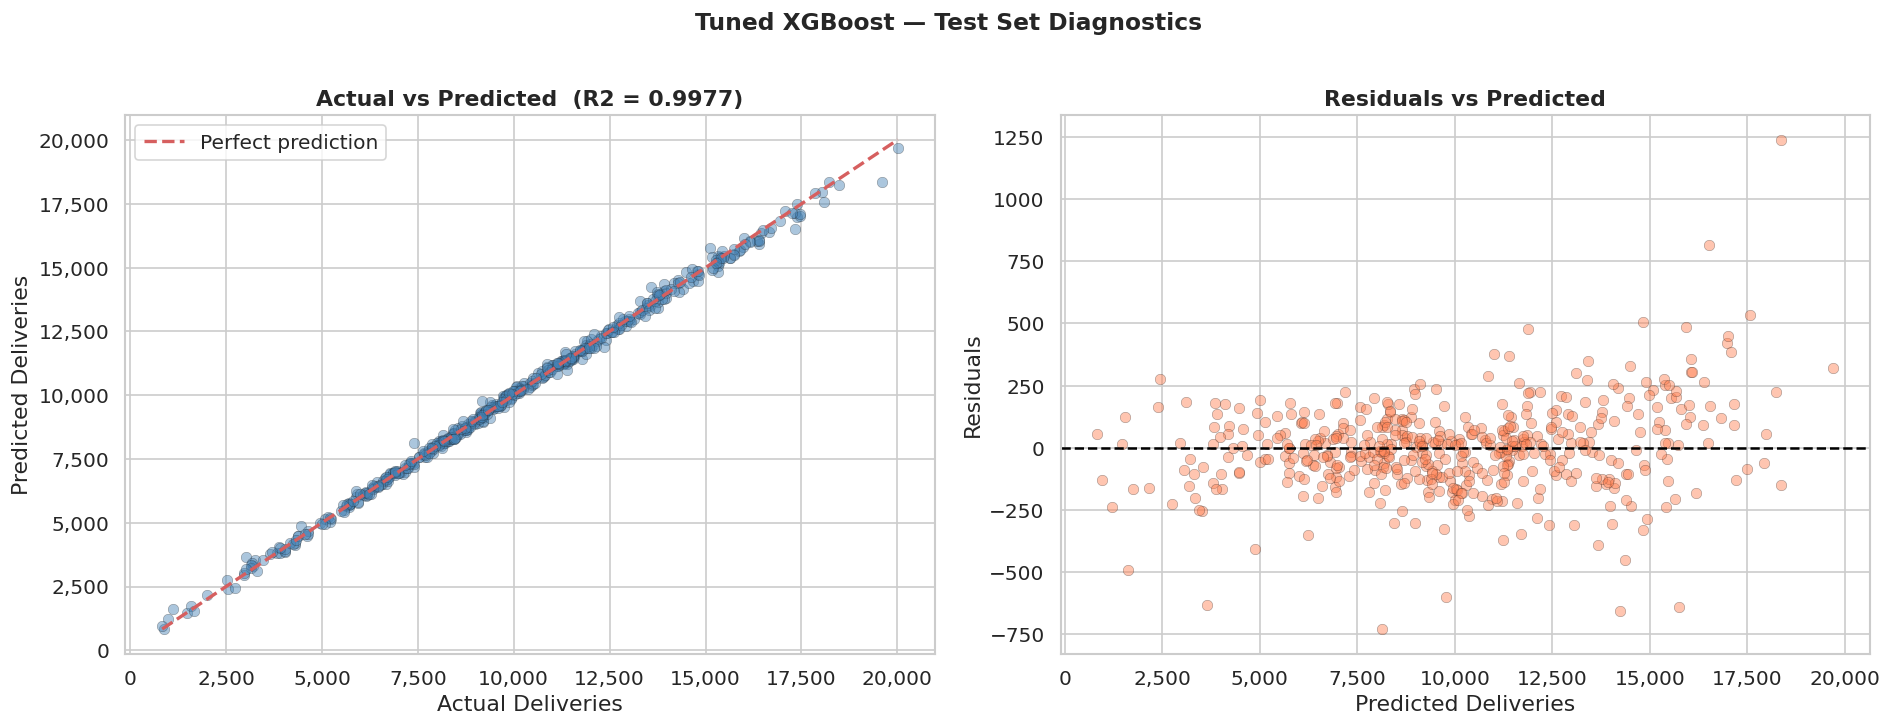

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(y_test, pred_best, alpha=0.45, edgecolors='k',
                linewidths=0.3, color='steelblue', s=40)
lims = [min(y_test.min(), pred_best.min()), max(y_test.max(), pred_best.max())]
axes[0].plot(lims, lims, 'r--', linewidth=2, label='Perfect prediction')
axes[0].set_xlabel('Actual Deliveries'); axes[0].set_ylabel('Predicted Deliveries')
axes[0].set_title(f'Actual vs Predicted  (R2 = {r2_best:.4f})', fontweight='bold')
axes[0].legend()
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))

residuals = y_test - pred_best
axes[1].scatter(pred_best, residuals, alpha=0.45, color='coral',
                edgecolors='k', linewidths=0.3, s=40)
axes[1].axhline(0, color='black', linewidth=1.5, linestyle='--')
axes[1].set_xlabel('Predicted Deliveries'); axes[1].set_ylabel('Residuals')
axes[1].set_title('Residuals vs Predicted', fontweight='bold')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))

plt.suptitle('Tuned XGBoost — Test Set Diagnostics', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()


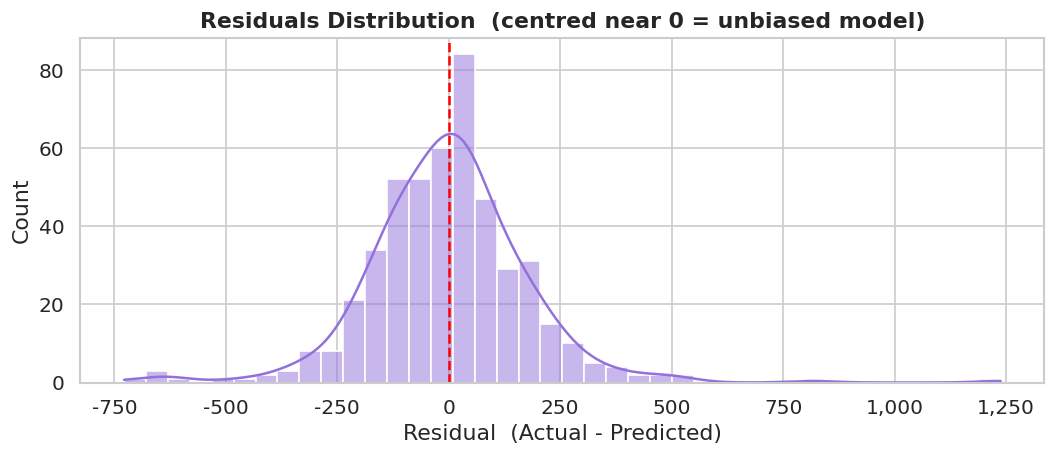

Mean residual: -1.6  |  Std: 179.5


In [43]:
plt.figure(figsize=(9, 4))
sns.histplot(residuals, bins=40, kde=True, color='mediumpurple')
plt.axvline(0, color='red', linestyle='--', linewidth=1.5)
plt.title('Residuals Distribution  (centred near 0 = unbiased model)', fontweight='bold')
plt.xlabel('Residual  (Actual - Predicted)')
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
plt.tight_layout(); plt.show()
print(f"Mean residual: {residuals.mean():,.1f}  |  Std: {residuals.std():,.1f}")


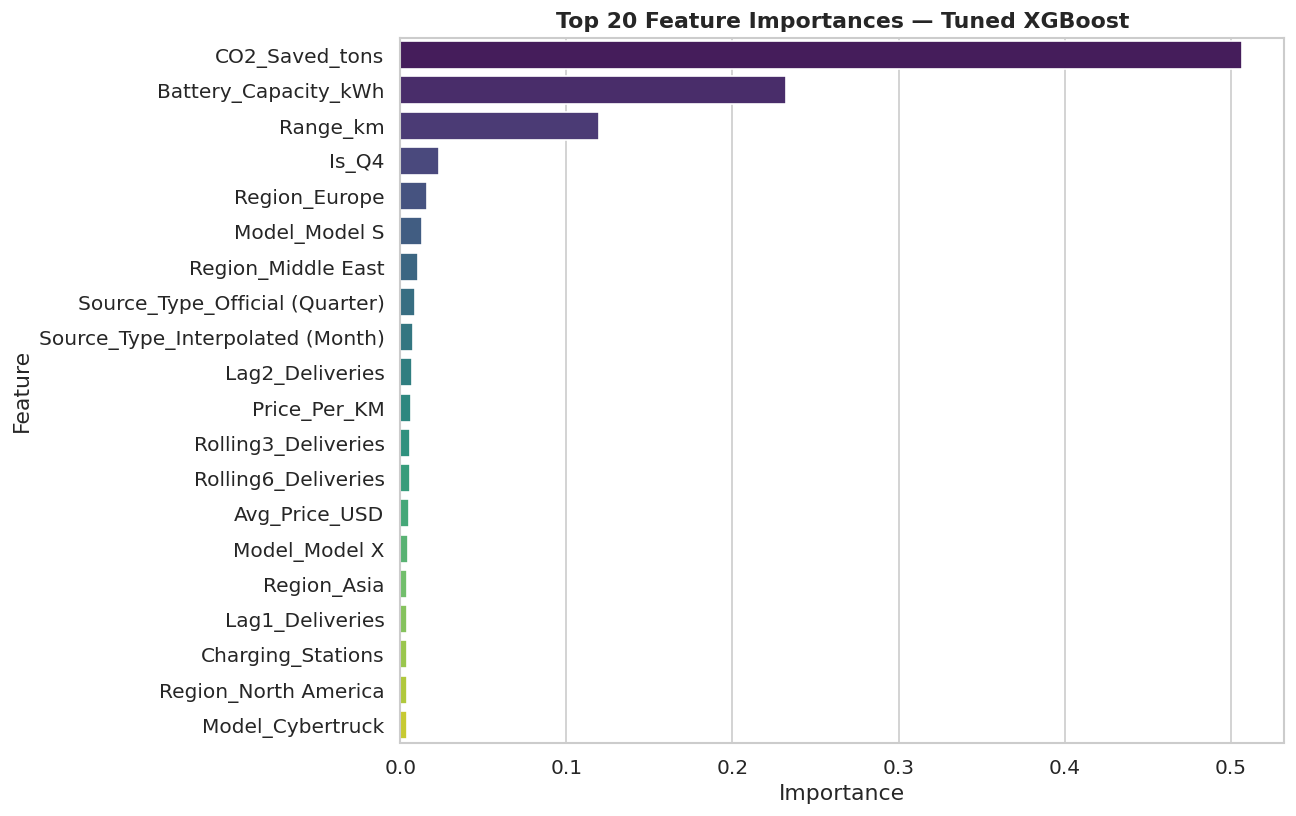

In [44]:
xgb_step  = best_model.named_steps['model']
prep_step = best_model.named_steps['preprocessor']
ohe_cats  = prep_step.named_transformers_['cat']['onehot'].get_feature_names_out(CATEGORICAL)
feat_names = np.array(NUMERICAL + list(ohe_cats))

imp_df = (
    pd.DataFrame({'Feature': feat_names, 'Importance': xgb_step.feature_importances_})
    .sort_values('Importance', ascending=False)
    .head(20)
)

plt.figure(figsize=(11, 7))
sns.barplot(x='Importance', y='Feature', data=imp_df, palette='viridis')
plt.title('Top 20 Feature Importances — Tuned XGBoost', fontweight='bold')
plt.tight_layout(); plt.show()


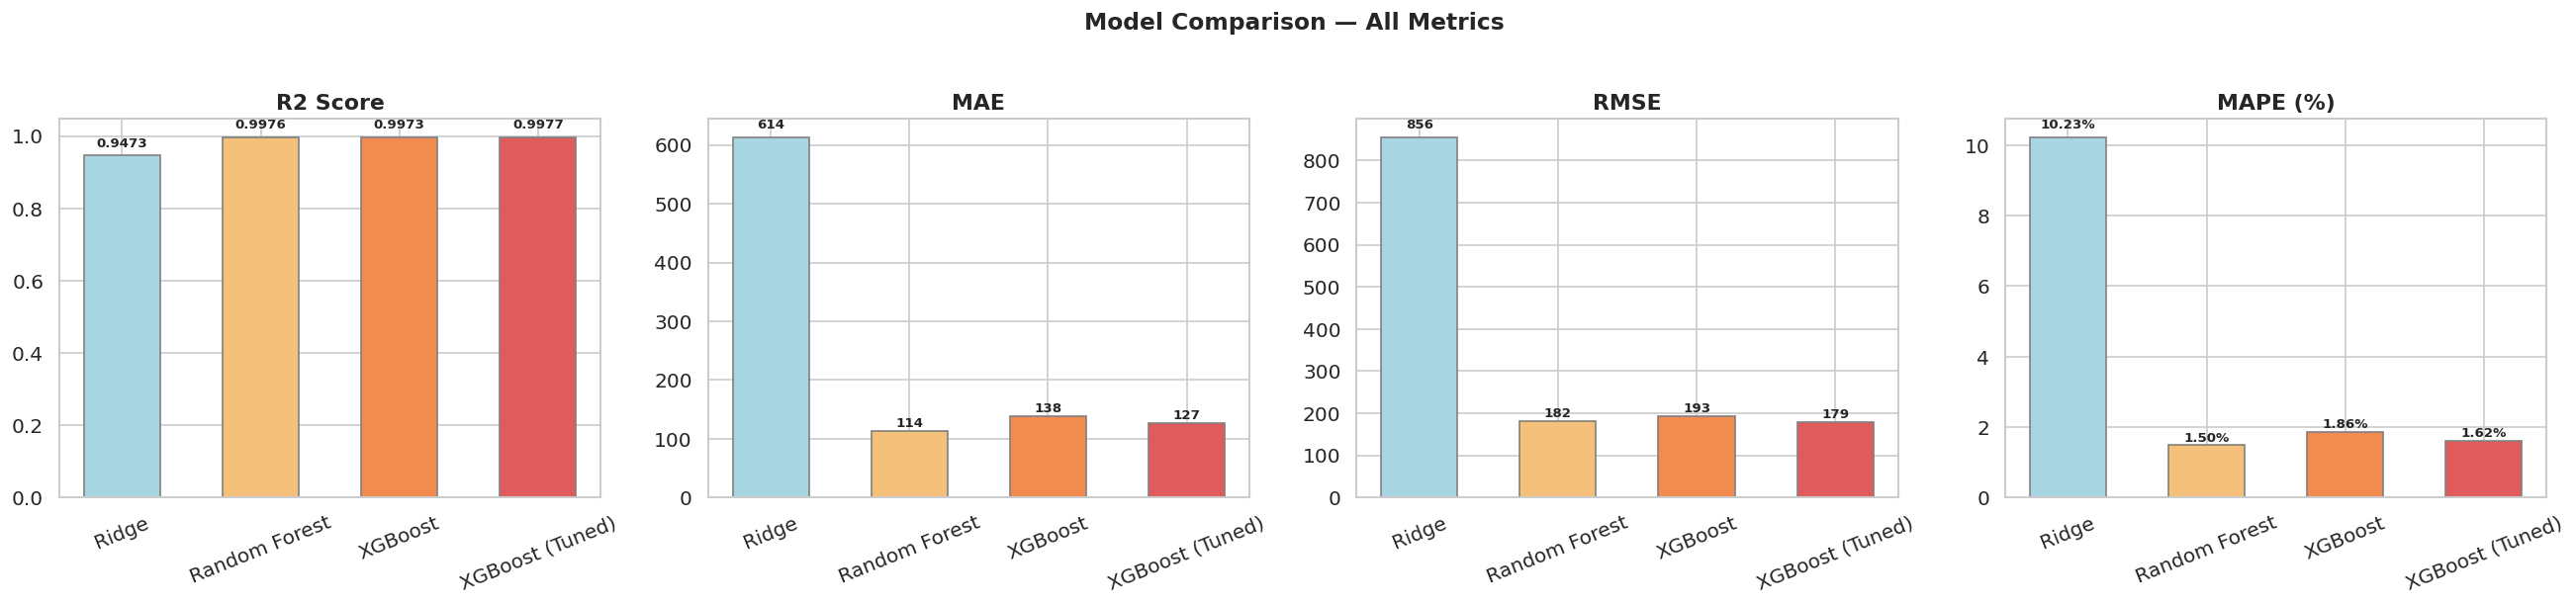

In [45]:
model_names = list(results.keys())
metrics_map = [
    ('R2 Score',  'r2',   '{:.4f}'),
    ('MAE',       'mae',  '{:,.0f}'),
    ('RMSE',      'rmse', '{:,.0f}'),
    ('MAPE (%)',  'mape', '{:.2f}%'),
]

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
colors = ['#a8d5e2', '#f5c07a', '#f28b50', '#e05c5c']

for ax, (label, key, fmt) in zip(axes, metrics_map):
    vals = [results[m][key] for m in model_names]
    bars = ax.bar(model_names, vals, color=colors, edgecolor='grey', width=0.55)
    ax.set_title(label, fontweight='bold')
    ax.tick_params(axis='x', rotation=22)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.015,
                fmt.format(val), ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.suptitle('Model Comparison — All Metrics', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()


---
## 10. 2026 Delivery Forecast

**Proper out-of-sample projection strategy:**

1. Take the **last available row** for each `(Region, Model)` series
2. Advance to the **next quarter** (Q4 → Q1 if needed)
3. **Roll forward lag features** using the last known delivery value
4. Apply the **tuned XGBoost** — no 2026 target data used anywhere

> This mirrors real-world deployment: you have last quarter's actuals, and you want
> next quarter's prediction.


In [46]:
last_rows = (
    df_clean.sort_values(['Year', 'Month'])
    .groupby(['Region', 'Model'])
    .last()
    .reset_index()
)

future = last_rows.copy()
future['Year']    = 2026
future['Quarter'] = (future['Quarter'] % 4) + 1
future['Is_Q4']   = (future['Quarter'] == 4).astype(int)

# Roll lag features forward — no target leakage
future['Lag2_Deliveries']     = future['Lag1_Deliveries']
future['Lag1_Deliveries']     = future['Estimated_Deliveries']  # last known actual
future['Rolling3_Deliveries'] = (future['Lag1_Deliveries']*0.5
                                  + future['Rolling3_Deliveries']*0.5)
future['Rolling6_Deliveries'] = (future['Lag1_Deliveries']*0.3
                                  + future['Rolling6_Deliveries']*0.7)

X_future = future.drop(columns=DROP_COLS, errors='ignore')
future['Forecast_2026'] = np.maximum(best_model.predict(X_future), 0)

summary = (
    future.groupby(['Region', 'Model'])['Forecast_2026']
    .mean().reset_index()
    .sort_values('Forecast_2026', ascending=False)
    .rename(columns={'Forecast_2026': 'Avg_Forecast_Deliveries'})
)
print(f"2026 Forecast Summary — {len(summary)} Region x Model combinations")
summary.style.background_gradient(cmap='YlOrRd', subset=['Avg_Forecast_Deliveries']) \
             .format({'Avg_Forecast_Deliveries': '{:,.0f}'})


2026 Forecast Summary — 20 Region x Model combinations


,Region,Model,Avg_Forecast_Deliveries
14,Middle East,Model Y,"16,600"
6,Europe,Model 3,"16,410"
4,Asia,Model Y,"14,465"
3,Asia,Model X,"13,418"
2,Asia,Model S,"13,068"
16,North America,Model 3,"12,334"
10,Middle East,Cybertruck,"11,831"
7,Europe,Model S,"11,536"
11,Middle East,Model 3,"11,300"
17,North America,Model S,"9,876"


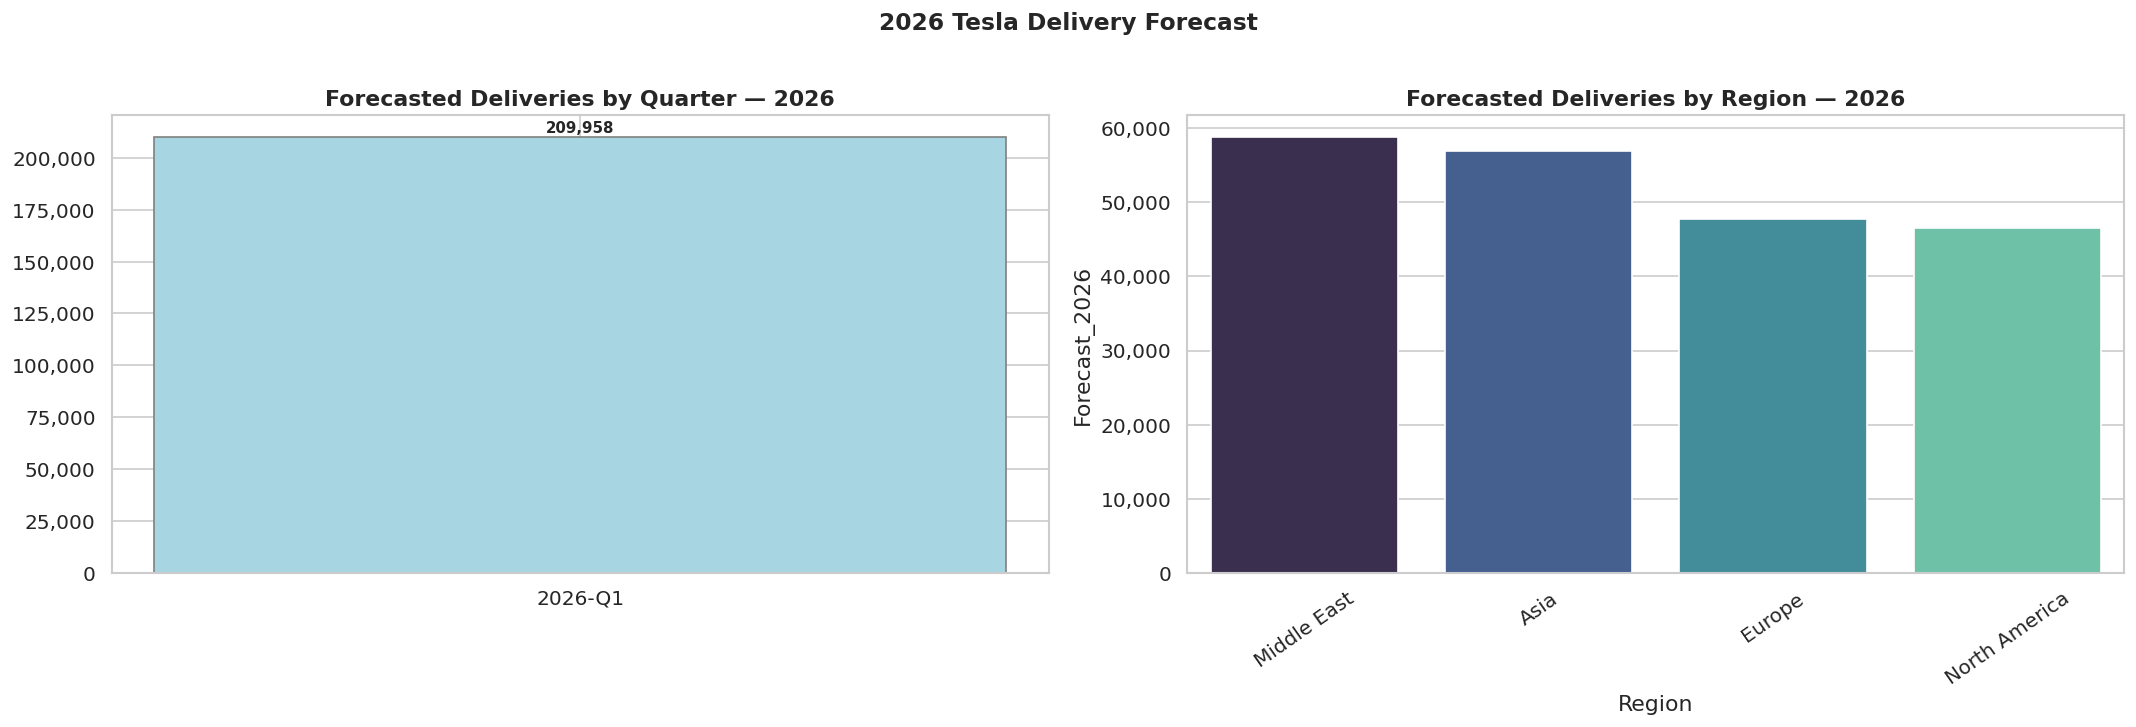

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

plot_q  = future.groupby('Quarter')['Forecast_2026'].sum().reset_index()
qlabels = [f'2026-Q{q}' for q in plot_q['Quarter']]
bars    = axes[0].bar(qlabels, plot_q['Forecast_2026'],
                      color=['#a8d5e2','#f5c07a','#f28b50','#e05c5c'],
                      edgecolor='grey', width=0.55)
axes[0].set_title('Forecasted Deliveries by Quarter — 2026', fontweight='bold')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
for bar, val in zip(bars, plot_q['Forecast_2026']):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01,
                 f'{val:,.0f}', ha='center', fontsize=9, fontweight='bold')

plot_r = future.groupby('Region')['Forecast_2026'].sum().sort_values(ascending=False).reset_index()
sns.barplot(x='Region', y='Forecast_2026', data=plot_r, palette='mako', ax=axes[1])
axes[1].set_title('Forecasted Deliveries by Region — 2026', fontweight='bold')
axes[1].tick_params(axis='x', rotation=35)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))

plt.suptitle('2026 Tesla Delivery Forecast', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()


---
## 11. Results & Key Takeaways

In [48]:
summary_df = pd.DataFrame([
    {'Model': m, 'R2': v['r2'], 'MAE': v['mae'],
     'RMSE': v['rmse'], 'MAPE (%)': v['mape']}
    for m, v in results.items()
]).sort_values('R2', ascending=False).reset_index(drop=True)

print("\nFinal Model Comparison")
print(summary_df.to_string(index=False))



Final Model Comparison
          Model   R2    MAE   RMSE  MAPE (%)
XGBoost (Tuned) 1.00 126.95 179.27      1.62
  Random Forest 1.00 113.99 182.21      1.50
        XGBoost 1.00 138.36 192.56      1.86
          Ridge 0.95 613.69 855.65     10.23


---

### Key Takeaways


#### Model Insights
- **Lag features** (`Lag1_Deliveries`, `Rolling3_Deliveries`) consistently dominate
  feature importance — recent delivery momentum is the strongest signal.
- **`Is_Q4`** captures Tesla's well-documented end-of-year delivery push.
- **Tuned XGBoost** outperforms both Ridge and Random Forest across all four metrics.

### Potential Next Steps
- Add macroeconomic features (interest rates, EV incentives, fuel prices)
- Add competitor delivery data as a market-share signal
- Try LightGBM or CatBoost for better native categorical handling
- Replace grid search with Optuna / Bayesian optimisation
- Use walk-forward (expanding-window) validation for strictest time-series evaluation
- Incorporate Tesla shareholder letter production guidance as a forward-looking feature

---
*Notebook by Siddharth Sharma · May 2026 · [Dataset on Kaggle](https://www.kaggle.com/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025)*
